# AddressCLIP Transfer Learning: Adding Novelties to Pre-trained Model
## Fine-tuning on Full Dataset with Hard Negatives + Geographic Loss

This notebook:
1. **Loads** pre-trained model from `major_project_copy_2` (100 epochs)
2. **Adds** Hard Negative Mining + Geographic Loss novelties
3. **Fine-tunes** on FULL dataset for 10 epochs
4. **Compares** results with baseline to show improvement

Expected improvement: **+3-7%** on SA metrics

## 1. Setup and Ensure Working Directory

In [5]:
import os
from pathlib import Path

# Ensure we're in the project root
while not Path("datasets").exists() and Path.cwd() != Path.cwd().parent:
    os.chdir("..")
    
if not Path("datasets").exists():
    raise FileNotFoundError("Cannot find 'datasets' folder. Are you in the right directory?")

print(f"✅ Working directory: {Path.cwd()}")
print(f"✅ Dataset exists: {Path('datasets/pitts-IAL').exists()}")
print(f"✅ Pre-trained checkpoint exists: {Path('runs/addressclip2/best.pt').exists()}")

✅ Working directory: /home/kush/Desktop/major_project_khush
✅ Dataset exists: True
✅ Pre-trained checkpoint exists: True


## 2. Import Libraries

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import clip

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

from scipy.io import loadmat
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

print("✅ All imports successful!")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

✅ All imports successful!
✅ PyTorch version: 2.1.1+cu118
✅ CUDA available: True
✅ GPU: Quadro P5000


## 3. Configuration for Transfer Learning
### Key differences from novelty_implementation.ipynb:
- `epochs: 10` (not 20) - only fine-tuning needed
- `learning_rate: 1e-5` (not 1e-4) - smaller LR for fine-tuning
- `max_samples: None` - use FULL dataset, not subset
- Load pre-trained checkpoint

In [7]:
from dataclasses import dataclass

@dataclass
class Config:
    """Transfer learning configuration"""
    # Paths
    data_root: str = "./datasets/pitts-IAL"
    pretrained_checkpoint: str = "./runs/addressclip2/best.pt"  # ← Pre-trained model
    run_dir: str = "./runs/novelty_transfer_learning"
    
    # Model
    proj_dim: int = 512
    model_name: str = "ViT-B/16"
    freeze_visual: bool = False
    freeze_text: bool = False
    
    # Training - TRANSFER LEARNING SETTINGS
    batch_size: int = 32
    epochs: int = 10  # ← REDUCED: only fine-tuning (was 20)
    learning_rate: float = 1e-5  # ← REDUCED: fine-tuning LR (was 1e-4)
    weight_decay: float = 0.01
    warmup_epochs: int = 1  # ← REDUCED: shorter warmup (was 2)
    
    # Loss weights - NOVELTIES ENABLED
    lambda_addr: float = 1.0
    lambda_cap: float = 0.2
    lambda_geo: float = 0.8
    lambda_geo_graph: float = 0.5  # NEW: Geographic graph loss
    
    # Loss parameters
    tau: float = 0.07
    grad_accum: int = 1
    fp16: bool = True
    hard_neg_temperature: float = 2.0
    geo_knn_neighbors: int = 5
    
    # Dataset - FULL DATA
    max_train_samples: int = None  # ← None = use ALL training data
    max_db_samples: int = None     # ← None = use ALL database data
    max_query_samples: int = None  # ← None = use ALL query data
    
    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42
    
    def __post_init__(self):
        Path(self.run_dir).mkdir(parents=True, exist_ok=True)

CFG = Config()

print("\n" + "="*70)
print("TRANSFER LEARNING CONFIGURATION")
print("="*70)
print(f"Device: {CFG.device}")
print(f"\nData Settings:")
print(f"  Training samples: FULL (all available)")
print(f"  Database samples: FULL (all available)")
print(f"  Query samples: FULL (all available)")
print(f"\nTraining Settings:")
print(f"  Base model: Pre-trained from {CFG.pretrained_checkpoint}")
print(f"  Fine-tune epochs: {CFG.epochs}")
print(f"  Learning rate: {CFG.learning_rate} (fine-tuning rate)")
print(f"  Warmup epochs: {CFG.warmup_epochs}")
print(f"\nNovelties Enabled:")
print(f"  Hard negative mining: ✓ (λ={CFG.lambda_addr})")
print(f"  Geographic loss (paper): ✓ (λ={CFG.lambda_geo})")
print(f"  Geographic k-NN loss: ✓ (λ={CFG.lambda_geo_graph})")
print(f"\nOutput: {CFG.run_dir}")
print("="*70)


TRANSFER LEARNING CONFIGURATION
Device: cuda

Data Settings:
  Training samples: FULL (all available)
  Database samples: FULL (all available)
  Query samples: FULL (all available)

Training Settings:
  Base model: Pre-trained from ./runs/addressclip2/best.pt
  Fine-tune epochs: 10
  Learning rate: 1e-05 (fine-tuning rate)
  Warmup epochs: 1

Novelties Enabled:
  Hard negative mining: ✓ (λ=1.0)
  Geographic loss (paper): ✓ (λ=0.8)
  Geographic k-NN loss: ✓ (λ=0.5)

Output: ./runs/novelty_transfer_learning


## 4. Utility Functions

In [8]:
def set_seed(seed):
    """Set random seed for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG.seed)
print(f"✅ Random seed set to {CFG.seed}")

✅ Random seed set to 42


## 5. Load Annotations and Coordinates

In [9]:
print("Loading annotations...")

data_root = Path(CFG.data_root)
train_json = data_root / "annotations" / "pitts_train.json"
db_json = data_root / "annotations" / "pitts_database.json"
q_json = data_root / "annotations" / "pitts_queries.json"

with open(train_json) as f:
    train_annotations = json.load(f)
    
with open(db_json) as f:
    db_annotations = json.load(f)
    
with open(q_json) as f:
    query_annotations = json.load(f)

print(f"✅ Training samples: {len(train_annotations)}")
print(f"✅ Database samples: {len(db_annotations)}")
print(f"✅ Query samples: {len(query_annotations)}")

# Load coordinates
print("\nLoading coordinates...")
coords_csv = data_root / "annotations" / "coords.csv"
if coords_csv.exists():
    coords_df = pd.read_csv(coords_csv)
    print(f"✅ Coordinates loaded: {len(coords_df)} entries")
else:
    print("⚠️  Coordinates CSV not found, will use defaults")
    coords_df = None

Loading annotations...
✅ Training samples: 177840
✅ Database samples: 57072
✅ Query samples: 19152

Loading coordinates...
✅ Coordinates loaded: 278064 entries


## 6. Hard Negative Mining Functions

In [10]:
def compute_address_similarity_matrix(addresses, model_name='all-MiniLM-L6-v2'):
    """Compute semantic similarity between all pairs of addresses"""
    print(f"\n[Hard Negatives] Computing address similarity for {len(addresses)} addresses...")
    print("Loading sentence transformer model...")
    
    model = SentenceTransformer(model_name)
    
    print("Encoding addresses...")
    embeddings = model.encode(addresses, batch_size=32, show_progress_bar=True, device=CFG.device)
    
    print("Computing cosine similarities...")
    similarity_matrix = cosine_similarity(embeddings)
    
    print(f"✅ Similarity matrix shape: {similarity_matrix.shape}")
    print(f"✅ Similarity range: [{similarity_matrix.min():.3f}, {similarity_matrix.max():.3f}]")
    
    return similarity_matrix

def get_hard_negative_weights(similarity_matrix, temperature=1.0):
    """Convert similarity matrix to hardness weights"""
    hardness = similarity_matrix.copy()
    np.fill_diagonal(hardness, 0)
    
    weights = np.exp(hardness * temperature)
    weights = weights / (weights.sum(axis=1, keepdims=True) + 1e-8)
    
    print(f"\nHard Negative Weights Statistics:")
    print(f"  Min: {weights.min():.6f}")
    print(f"  Max: {weights.max():.6f}")
    print(f"  Mean: {weights.mean():.6f}")
    
    return weights

print("✅ Hard negative functions loaded")

✅ Hard negative functions loaded


## 7. Model Architecture (Identical to novelty_implementation)

In [11]:
class LinearHead(nn.Module):
    """Projection head with L2 normalization"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)
    
    def forward(self, x):
        return F.normalize(self.fc(x), dim=-1)

class AddressCLIP(nn.Module):
    """AddressCLIP: Vision-Language Model for Address Localization"""
    def __init__(self, proj_dim=512, freeze_visual=False, freeze_text=False, device='cuda'):
        super().__init__()
        
        # Load pretrained CLIP
        print("Loading CLIP model...")
        self.clip, _ = clip.load(CFG.model_name, device=device, jit=False)
        self.clip.float()
        
        # Get dimensions
        img_dim = self.clip.visual.output_dim
        txt_dim = self.clip.text_projection.shape[1]
        
        print(f"  Image embedding dim: {img_dim}")
        print(f"  Text embedding dim: {txt_dim}")
        
        # Projection heads
        self.proj_image = LinearHead(img_dim, proj_dim)
        self.proj_address = LinearHead(txt_dim, proj_dim)
        self.proj_caption = LinearHead(txt_dim, proj_dim)
        
        if freeze_visual:
            for p in self.clip.visual.parameters():
                p.requires_grad = False
            print("  Visual encoder frozen")
        
        if freeze_text:
            for p in self.clip.transformer.parameters():
                p.requires_grad = False
            if hasattr(self.clip, 'token_embedding'):
                self.clip.token_embedding.weight.requires_grad = False
            if hasattr(self.clip, 'positional_embedding'):
                self.clip.positional_embedding.requires_grad = False
            if hasattr(self.clip, 'ln_final'):
                for p in self.clip.ln_final.parameters():
                    p.requires_grad = False
            print("  Text encoder frozen")
    
    def encode_image(self, images):
        img_features = self.clip.encode_image(images).float()
        return self.proj_image(img_features)
    
    def encode_text_raw(self, tokens):
        x = self.clip.token_embedding(tokens).type(self.clip.dtype)
        x = x + self.clip.positional_embedding.type(self.clip.dtype)
        x = x.permute(1, 0, 2)
        x = self.clip.transformer(x)
        x = x.permute(1, 0, 2)
        x = self.clip.ln_final(x).type(self.clip.dtype)
        x = x[torch.arange(tokens.shape[0]), tokens.argmax(dim=-1)] @ self.clip.text_projection
        return x
    
    def encode_text(self, tokens, which="address"):
        x = self.encode_text_raw(tokens)
        if which == "address":
            return self.proj_address(x)
        elif which == "caption":
            return self.proj_caption(x)
        else:
            raise ValueError(f"Unknown text type: {which}")
    
    def forward(self, images, addr_tokens, cap_tokens):
        v = self.encode_image(images)
        a = self.encode_text(addr_tokens, "address")
        c = self.encode_text(cap_tokens, "caption")
        return v, a, c

print("✅ Model architecture defined")

✅ Model architecture defined


## 8. Loss Functions

In [12]:
def clip_info_nce(v, t, tau=0.07):
    """InfoNCE contrastive loss (CLIP-style)"""
    B = v.size(0)
    v = F.normalize(v, dim=-1)
    t = F.normalize(t, dim=-1)
    logits = (v @ t.t()) / tau
    labels = torch.arange(B, device=v.device)
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.t(), labels)
    return 0.5 * (loss_i2t + loss_t2i)

# def clip_info_nce_with_hard_negatives(v, t, tau=0.07, hard_neg_weights=None, batch_indices=None):
#     """InfoNCE loss with hard negative weighting (NOVELTY #1)"""
#     B = v.size(0)
#     device = v.device
#     v = F.normalize(v, dim=-1)
#     t = F.normalize(t, dim=-1)
#     logits = (v @ t.t()) / tau
    
#     if hard_neg_weights is not None and batch_indices is not None:
#         batch_weights = hard_neg_weights[batch_indices][:, batch_indices]
#         batch_weights = torch.from_numpy(batch_weights).float().to(device)
#         mask = torch.zeros_like(batch_weights)
#         for i in range(B):
#             for j in range(B):
#                 if i != j:
#                     mask[i, j] = batch_weights[i, j]
#         logits_weighted = logits * (1 + 2 * mask)
#     else:
#         logits_weighted = logits
    
#     labels = torch.arange(B, device=device)
#     loss_v2t = F.cross_entropy(logits_weighted, labels)
#     loss_t2i = F.cross_entropy(logits_weighted.t(), labels)
#     return 0.5 * (loss_v2t + loss_t2i)

def clip_info_nce_with_hard_negatives(v, t, tau=0.07, hard_neg_weights=None, 
                                       batch_indices=None, sample_addr_indices=None):
    B = v.size(0)
    device = v.device
    v = F.normalize(v, dim=-1)
    t = F.normalize(t, dim=-1)
    logits = (v @ t.t()) / tau

    if hard_neg_weights is not None and batch_indices is not None:
        # Map sample indices → unique address indices
        if sample_addr_indices is not None:
            addr_indices = sample_addr_indices[batch_indices]
        else:
            addr_indices = batch_indices
            
        batch_weights = hard_neg_weights[addr_indices][:, addr_indices]
        batch_weights = torch.from_numpy(batch_weights).float().to(device)
        # np.fill_diagonal  # already zeroed during construction
        logits_weighted = logits * (1 + 2 * batch_weights)
    else:
        logits_weighted = logits

    labels = torch.arange(B, device=device)
    loss_v2t = F.cross_entropy(logits_weighted, labels)
    loss_t2i = F.cross_entropy(logits_weighted.t(), labels)
    return 0.5 * (loss_v2t + loss_t2i)

def compute_geography_loss(image_embeds, coords):
    """Geography-aware loss (Paper)"""
    B = image_embeds.size(0)
    if B < 2:
        return torch.tensor(0.0, device=image_embeds.device)
    
    coord_min = coords.min(dim=0, keepdim=True)[0]
    coord_max = coords.max(dim=0, keepdim=True)[0]
    coord_range = coord_max - coord_min
    coord_range = torch.where(coord_range > 1e-6, coord_range, torch.ones_like(coord_range))
    coords_norm = (coords - coord_min) / coord_range
    
    D_U = torch.cdist(coords_norm, coords_norm, p=1)
    D_U = D_U / 2.0
    
    v_norm = F.normalize(image_embeds, dim=-1)
    D_V = v_norm @ v_norm.t()
    
    target_sim = 1.0 - D_U
    loss = F.mse_loss(D_V, target_sim)
    return loss

def compute_geographic_knn_loss(image_embeds, coords, k=5, device='cuda'):
    """Geographic k-NN loss (NOVELTY #2)"""
    B = image_embeds.shape[0]
    if B < k + 1:
        return torch.tensor(0.0, device=device)
    
    geo_distances = torch.cdist(coords, coords, p=2)
    _, knn_indices = torch.topk(geo_distances, k=min(k+1, B), dim=1, largest=False)
    knn_indices = knn_indices[:, 1:k+1]
    
    loss = 0.0
    for i in range(B):
        query_embed = image_embeds[i:i+1]
        neighbor_embeds = image_embeds[knn_indices[i]]
        similarities = query_embed @ neighbor_embeds.t()
        distances = 1 - similarities
        loss += distances.mean()
    
    loss = loss / B
    return loss

print("✅ Loss functions defined")

✅ Loss functions defined


## 9. Dataset Classes

In [13]:
class PittsIALTrain(Dataset):
    """Training dataset"""
    def __init__(self, annotations, data_root, coords_df=None, max_samples=None):
        self.data_root = Path(data_root)
        self.coords_df = coords_df
        
        # if isinstance(annotations, dict):
        #     self.annotations = list(annotations.values())
        # else:
        #     self.annotations = annotations

        if isinstance(annotations, dict):
            # Store as (key, values) so the image path key is preserved
            self.annotations = list(annotations.items())
        else:
            self.annotations = annotations
                
        if max_samples:
            self.annotations = self.annotations[:max_samples]
        
        self.image_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.48145466, 0.4578275, 0.40821073],
                std=[0.26862954, 0.26130258, 0.27577711]
            )
        ])
    
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        # item = self.annotations[idx]
        
        # if isinstance(item, dict):
        #     img_path_str = item['image']
        #     address = item.get('address', 'unknown address')
        #     caption = item.get('caption', address)
        # elif isinstance(item, list):
        #     img_path_str = item[-1] if len(item) > 3 else '000/database/0.jpg'
        #     address = str(item[2]) if len(item) > 2 else 'unknown address'
        #     caption = str(item[1]) if len(item) > 1 else address
        # else:
        #     raise ValueError(f"Unknown annotation format: {type(item)}")

        # In __getitem__, replace the isinstance block:
        item = self.annotations[idx]

        if isinstance(item, tuple):
            # Dict-loaded: (key=img_path, vals=[caption, addr_verbose, addr_canon])
            img_path_str = item[0]
            vals = item[1]
            caption = str(vals[0]) if len(vals) > 0 else ""
            addr_verbose = str(vals[1]) if len(vals) > 1 else ""
            addr_canon  = str(vals[2]) if len(vals) > 2 else addr_verbose
            address = addr_canon.strip() or addr_verbose.strip()
            cap_text = f"{caption} {address}" if caption else address
        elif isinstance(item, dict):
            img_path_str = item['image']
            address  = item.get('address', 'unknown address')
            cap_text = item.get('caption', address)
        else:
            raise ValueError(f"Unknown annotation format: {type(item)}")        
        
        if isinstance(img_path_str, int):
            idx_str = str(img_path_str).zfill(6)
            folder = idx_str[:3]
            img_path = self.data_root / "images" / folder / "database" / f"{idx_str}.jpg"
        else:
            img_path = self.data_root / img_path_str
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color='gray')
        
        image = self.image_transform(image)
        
        addr_tokens = clip.tokenize(address, truncate=True)[0]
        cap_tokens = clip.tokenize(caption, truncate=True)[0]
        
        # coords = torch.tensor([0.0, 0.0], dtype=torch.float32)
        # if self.coords_df is not None:
        #     img_filename = Path(str(img_path_str)).name if isinstance(img_path_str, str) else f"{img_path_str}.jpg"
        #     matching = self.coords_df[self.coords_df['filename'] == img_filename]
        #     if len(matching) > 0:
        #         coords = torch.tensor(
        #             [matching.iloc[0]['utm_easting'], matching.iloc[0]['utm_northing']],
        #             dtype=torch.float32
        #         )
        
        coords = torch.tensor([0.0, 0.0], dtype=torch.float32)
        if self.coords_df is not None:
            # Try full relative path first, then basename
            rel_path = str(img_path_str).lstrip("./")
            basename  = Path(rel_path).name
            
            match = self.coords_df[self.coords_df['filename'] == rel_path]
            if len(match) == 0:
                match = self.coords_df[self.coords_df['filename'] == basename]
            
            if len(match) > 0:
                coords = torch.tensor(
                    [match.iloc[0]['utm_easting'], match.iloc[0]['utm_northing']],
                    dtype=torch.float32
                )


        return {
            'images': image,
            'addr_tokens': addr_tokens,
            'cap_tokens': cap_tokens,
            'coords': coords,
            'indices': idx,
            'address': address
        }

def collate_batch(batch):
    return {
        'images': torch.stack([b['images'] for b in batch]),
        'addr_tokens': torch.stack([b['addr_tokens'] for b in batch]),
        'cap_tokens': torch.stack([b['cap_tokens'] for b in batch]),
        'coords': torch.stack([b['coords'] for b in batch]),
        'indices': np.array([b['indices'] for b in batch]),
        'addresses': [b['address'] for b in batch]
    }

print("✅ Dataset classes defined")

✅ Dataset classes defined


## 10. Create Full Dataset DataLoaders
### CRITICAL: max_samples=None means use ALL data, not subset!

In [14]:
print("Creating datasets with FULL data (no max_samples limit)...\n")

train_ds = PittsIALTrain(
    train_annotations,
    CFG.data_root,
    coords_df,
    max_samples=None  # ← FULL data
)

db_ds = PittsIALTrain(
    db_annotations,
    CFG.data_root,
    coords_df,
    max_samples=None  # ← FULL data
)

query_ds = PittsIALTrain(
    query_annotations,
    CFG.data_root,
    coords_df,
    max_samples=None  # ← FULL data
)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.batch_size,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=0
)

db_loader = DataLoader(
    db_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=0
)

query_loader = DataLoader(
    query_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=0
)

print("✅ FULL Dataset Summary:")
print(f"   Training samples: {len(train_ds)} (vs 1000 in subset)")
print(f"   Database samples: {len(db_ds)} (vs 2000 in subset)")
print(f"   Query samples: {len(query_ds)} (vs 200 in subset)")
print(f"\n✅ DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Database batches: {len(db_loader)}")
print(f"   Query batches: {len(query_loader)}")

Creating datasets with FULL data (no max_samples limit)...

✅ FULL Dataset Summary:
   Training samples: 177840 (vs 1000 in subset)
   Database samples: 57072 (vs 2000 in subset)
   Query samples: 19152 (vs 200 in subset)

✅ DataLoaders created:
   Train batches: 5558
   Database batches: 1784
   Query batches: 599


## 11. Compute Hard Negative Weights on FULL Training Data
### This may take 5-10 minutes depending on dataset size

In [15]:
print("Computing hard negative weights on UNIQUE addresses only...\n")

# Step 1: Extract all addresses
addresses_list = []
# for i in range(len(train_ds)):
#     item = train_ds.annotations[i]
#     if isinstance(item, dict):
#         addresses_list.append(item.get('address', 'unknown address'))
#     elif isinstance(item, list):
#         addresses_list.append(str(item[2]) if len(item) > 2 else 'unknown address')

for i in range(len(train_ds)):
    item = train_ds.annotations[i]
    if isinstance(item, tuple):                          # ← ADD THIS BRANCH
        vals = item[1]
        addr_canon   = str(vals[2]) if len(vals) > 2 else ""
        addr_verbose = str(vals[1]) if len(vals) > 1 else ""
        address = addr_canon.strip() or addr_verbose.strip()
        addresses_list.append(address)
    elif isinstance(item, dict):
        addresses_list.append(item.get('address', 'unknown address'))
    elif isinstance(item, list):
        addresses_list.append(str(item[2]) if len(item) > 2 else 'unknown address')

print(f"✅ Total training samples: {len(addresses_list)}")

# Step 2: Get unique addresses and build mapping
unique_addresses = list(dict.fromkeys(addresses_list))  # preserves order, removes duplicates
addr_to_idx = {addr: i for i, addr in enumerate(unique_addresses)}
sample_to_unique = np.array([addr_to_idx[a] for a in addresses_list])

print(f"✅ Unique addresses: {len(unique_addresses)}")
print(f"   Memory for similarity matrix: "
      f"{len(unique_addresses)**2 * 4 / 1e6:.1f} MB (safe!)")

# Step 3: Compute similarity ONLY on unique addresses
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("\nEncoding unique addresses...")
sent_model = SentenceTransformer('all-MiniLM-L6-v2')
unique_embeddings = sent_model.encode(
    unique_addresses,
    batch_size=64,
    show_progress_bar=True,
    device=CFG.device
)

print("Computing cosine similarity (unique addresses only)...")
unique_sim_matrix = cosine_similarity(unique_embeddings)  # shape: (419, 419) — tiny!
print(f"✅ Similarity matrix shape: {unique_sim_matrix.shape}")

# Step 4: Compute weights on unique matrix
np.fill_diagonal(unique_sim_matrix, 0)
unique_weights = np.exp(unique_sim_matrix * CFG.hard_neg_temperature)
unique_weights = unique_weights / (unique_weights.sum(axis=1, keepdims=True) + 1e-8)

# Step 5: Store the unique index mapping (used during training)
# We'll use sample_to_unique to look up weights per batch
hard_negative_weights = unique_weights          # shape: (419, 419)
sample_addr_indices = sample_to_unique          # shape: (177840,) — maps sample→unique addr idx

print(f"\n✅ Hard negative weights computed!")
print(f"   Weight matrix shape: {hard_negative_weights.shape}")
print(f"   Sample mapping shape: {sample_addr_indices.shape}")

Computing hard negative weights on UNIQUE addresses only...

✅ Total training samples: 177840
✅ Unique addresses: 428
   Memory for similarity matrix: 0.7 MB (safe!)

Encoding unique addresses...


Batches: 100%|██████████| 7/7 [00:00<00:00, 27.90it/s]

Computing cosine similarity (unique addresses only)...
✅ Similarity matrix shape: (428, 428)

✅ Hard negative weights computed!
   Weight matrix shape: (428, 428)
   Sample mapping shape: (177840,)


## 12. Initialize Model

In [16]:
print("Initializing AddressCLIP model...")
model = AddressCLIP(
    proj_dim=CFG.proj_dim,
    freeze_visual=CFG.freeze_visual,
    freeze_text=CFG.freeze_text,
    device=CFG.device
)
model = model.to(CFG.device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model initialized")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

Initializing AddressCLIP model...
Loading CLIP model...
  Image embedding dim: 512
  Text embedding dim: 512

✅ Model initialized
   Total parameters: 150,408,705
   Trainable parameters: 150,408,705


## 13. Load Pre-trained Weights from major_project_copy_2
### KEY STEP: Load 100-epoch trained model

In [17]:
# print("\n" + "="*70)
# print("LOADING PRE-TRAINED WEIGHTS")
# print("="*70)

# checkpoint_path = Path(CFG.pretrained_checkpoint)

# if not checkpoint_path.exists():
#     raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

# print(f"\nLoading checkpoint from: {checkpoint_path}")
# print(f"Checkpoint size: {checkpoint_path.stat().st_size / 1e9:.1f} GB")

# checkpoint = torch.load(checkpoint_path, map_location=CFG.device)

# # Load model weights
# model.load_state_dict(checkpoint['model_state_dict'])

# print("\n✅ Pre-trained weights loaded successfully!")
# print(f"   Source: {CFG.pretrained_checkpoint}")
# print(f"   Original training: 100 epochs on full dataset")
# print(f"\n🔧 Fine-tuning setup:")
# print(f"   Starting point: Pre-trained model (100 epochs)")
# print(f"   Fine-tune epochs: {CFG.epochs}")
# print(f"   Learning rate: {CFG.learning_rate} (reduced for fine-tuning)")
# print(f"   Dataset: FULL (all {len(train_ds)} training samples)")
# print(f"\n🎯 Novelties being added:")
# print(f"   1. Hard Negative Mining (weight loss by address similarity)")
# print(f"   2. Geographic k-NN Loss (enforce neighborhood structure)")
# print("="*70)
checkpoint_path = Path(CFG.pretrained_checkpoint)
checkpoint = torch.load(checkpoint_path, map_location=CFG.device)

print("Keys in checkpoint:", list(checkpoint.keys()))

# Handle different checkpoint formats
if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
elif 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
elif 'model' in checkpoint:
    state_dict = checkpoint['model']
else:
    # Checkpoint IS the state dict directly
    state_dict = checkpoint

# Load with strict=False to handle any minor key mismatches
missing, unexpected = model.load_state_dict(state_dict, strict=False)

if missing:
    print(f"⚠️  Missing keys ({len(missing)}): {missing[:5]}")
if unexpected:
    print(f"⚠️  Unexpected keys ({len(unexpected)}): {unexpected[:5]}")

print("\n✅ Pre-trained weights loaded successfully!")

Keys in checkpoint: ['model', 'cfg', 'history', 'epoch']

✅ Pre-trained weights loaded successfully!


## 14. Setup Optimizer and Scheduler

In [18]:
# Optimizer with REDUCED learning rate for fine-tuning
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.learning_rate,  # 1e-5 (reduced from 1e-4)
    weight_decay=CFG.weight_decay
)

# Learning rate scheduler
num_training_steps = len(train_loader) * CFG.epochs
warmup_steps = len(train_loader) * CFG.warmup_epochs

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    return max(0.0, float(num_training_steps - current_step) / float(max(1, num_training_steps - warmup_steps)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Scaler for mixed precision
scaler = torch.cuda.amp.GradScaler()

print(f"✅ Optimizer initialized")
print(f"   Learning rate: {CFG.learning_rate}")
print(f"   Weight decay: {CFG.weight_decay}")
print(f"\n✅ Learning rate scheduler initialized")
print(f"   Total training steps: {num_training_steps}")
print(f"   Warmup steps: {warmup_steps} ({CFG.warmup_epochs} epochs)")

✅ Optimizer initialized
   Learning rate: 1e-05
   Weight decay: 0.01

✅ Learning rate scheduler initialized
   Total training steps: 55580
   Warmup steps: 5558 (1 epochs)


## 15. Training Function with Novelties

In [19]:
def train_epoch_with_novelties(model, train_loader, optimizer, scheduler, scaler, cfg, epoch,
                                 hard_neg_weights=None):
    """Training loop with hard negatives and geographic loss"""
    model.train()
    
    running = {
        "addr": 0.0,
        "cap": 0.0,
        "geo": 0.0,
        "geo_graph": 0.0,
        "total": 0.0
    }
    
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}")
    
    for it, batch in enumerate(pbar):
        imgs = batch["images"].to(cfg.device, non_blocking=True)
        atok = batch["addr_tokens"].to(cfg.device, non_blocking=True)
        ctok = batch["cap_tokens"].to(cfg.device, non_blocking=True)
        coords = batch["coords"].to(cfg.device, non_blocking=True)
        batch_indices = batch.get("indices", None)
        
        with torch.cuda.amp.autocast(enabled=cfg.fp16):
            # Forward pass
            v, a, c = model(imgs, atok, ctok)
            
            # Losses
            # L_addr = clip_info_nce_with_hard_negatives(
            #     v, a, cfg.tau,
            #     hard_neg_weights=hard_neg_weights,
            #     batch_indices=batch_indices
            # )

            L_addr = clip_info_nce_with_hard_negatives(
            v, a, cfg.tau,
            hard_neg_weights=hard_neg_weights,
            batch_indices=batch_indices,
            sample_addr_indices=sample_addr_indices   # ← add this
)
            
            L_cap = clip_info_nce(v, c, cfg.tau)
            L_geo = compute_geography_loss(v, coords)
            L_geo_graph = compute_geographic_knn_loss(v, coords, k=5, device=cfg.device)
            
            # Combined loss
            loss = (
                cfg.lambda_addr * L_addr +
                cfg.lambda_cap * L_cap +
                cfg.lambda_geo * L_geo +
                cfg.lambda_geo_graph * L_geo_graph
            )
            
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"\n⚠️  NaN/Inf loss at step {it}!")
                optimizer.zero_grad(set_to_none=True)
                continue
        
        # Backward
        scaler.scale(loss / cfg.grad_accum).backward()
        
        # Step
        if (it + 1) % cfg.grad_accum == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
        
        # Track losses
        running["addr"] += L_addr.item()
        running["cap"] += L_cap.item()
        running["geo"] += L_geo.item()
        running["geo_graph"] += L_geo_graph.item()
        running["total"] += loss.item()
        
        # Update progress
        if it % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'lr': f'{current_lr:.2e}'
            })
    
    # Average losses
    steps = len(train_loader)
    for k in running:
        running[k] /= steps
    
    return running

print("✅ Training function defined")

✅ Training function defined


## 16. Evaluation Function

In [26]:
def evaluate_with_distance_thresholds(model, query_loader, db_loader, cfg,
                                       distance_thresholds=[100, 500, 1000, 5000]):
    """Evaluate with distance-based metrics"""
    model.eval()
    all_distances = []
    
    with torch.no_grad():
        # Get all database embeddings
        print("Computing database embeddings...")
        db_embeddings = []
        db_coords = []
        
        for batch in tqdm(db_loader, desc="DB embeddings"):
            imgs = batch["images"].to(cfg.device)
            embeds = model.encode_image(imgs)
            db_embeddings.append(embeds.cpu())
            db_coords.append(batch["coords"])
        
        db_embeddings = torch.cat(db_embeddings, dim=0)
        db_coords = torch.cat(db_coords, dim=0)
        
        # Move to device
        db_embeddings = db_embeddings.to(cfg.device)
        db_coords = db_coords.to(cfg.device)
        
        # Query each test image
        print("Retrieving nearest neighbors...")
        for batch in tqdm(query_loader, desc="Retrieval"):
            query_imgs = batch["images"].to(cfg.device)
            query_coords = batch["coords"].to(cfg.device)
            
            query_embeds = model.encode_image(query_imgs)
            
            # Find nearest
            distances = torch.cdist(query_embeds, db_embeddings, p=2)
            nearest_idx = distances.argmin(dim=1)
            
            # Get coordinates
            predicted_coords = db_coords[nearest_idx]
            
            # Compute spatial distance in meters
            spatial_distances = torch.sqrt(
                (query_coords[:, 0] - predicted_coords[:, 0])**2 +
                (query_coords[:, 1] - predicted_coords[:, 1])**2
            )
            
            all_distances.extend(spatial_distances.cpu().numpy())
    
    all_distances = np.array(all_distances)
    
    # Compute metrics
    results = {'all_distances': all_distances, 'stats': {}}
    
    print("\nDistance-Based Accuracy:")
    print("-" * 40)
    for threshold in distance_thresholds:
        accuracy = (all_distances <= threshold).mean()
        results['stats'][f'accuracy_{threshold}m'] = accuracy
        print(f"  Within {threshold:5d}m: {accuracy*100:6.2f}%")
    
    # Additional stats
    results['stats']['median_distance'] = np.median(all_distances)
    results['stats']['mean_distance'] = np.mean(all_distances)
    results['stats']['percentile_95'] = np.percentile(all_distances, 95)
    
    print("-" * 40)
    print(f"  Median error: {np.median(all_distances):.1f}m")
    print(f"  Mean error:   {np.mean(all_distances):.1f}m")
    
    return results

print("✅ Evaluation function defined")

✅ Evaluation function defined


In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Thu Apr 23 16:01:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro P5000                   Off |   00000000:02:00.0  On |                  Off |
| 28%   45C    P5             14W /  180W |   16125MiB /  16384MiB |     14%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
import os
os.kill(2603767, 9)
print("✅ Killed stale process 2603767")

✅ Killed stale process 2603767


In [20]:
import subprocess, torch

# Verify GPU memory freed
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

# Also clear current session's cache
torch.cuda.empty_cache()
print(f"✅ GPU memory now free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")

Thu Apr 30 16:58:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro P5000                   Off |   00000000:02:00.0  On |                  Off |
| 36%   52C    P0             46W /  180W |    2268MiB /  16384MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [21]:
CFG.batch_size = 16
CFG.grad_accum = 2

train_loader = DataLoader(
    train_ds, batch_size=CFG.batch_size,
    shuffle=True, collate_fn=collate_batch, num_workers=0
)
print(f"✅ Effective batch size: {CFG.batch_size * CFG.grad_accum} (same as before)")
print(f"✅ Batches per epoch: {len(train_loader)}")

✅ Effective batch size: 32 (same as before)
✅ Batches per epoch: 11115


## 17. Main Training Loop with Checkpointing
### This will train for 10 epochs on FULL dataset with novelties

In [22]:
print("\n" + "="*70)
print("TRANSFER LEARNING: Fine-tuning with Novelties")
print("="*70)

train_logs = []

# Create run directory and CSV file
run_dir = Path(CFG.run_dir)
run_dir.mkdir(parents=True, exist_ok=True)
log_csv_path = run_dir / "train_log.csv"
checkpoint_dir = run_dir / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Write CSV header
csv_header = "epoch,total,addr,cap,geo,geo_graph,learning_rate\n"
with open(log_csv_path, "w") as f:
    f.write(csv_header)

print(f"\n📊 Logs will be saved to: {log_csv_path}")
print(f"💾 Checkpoints will be saved to: {checkpoint_dir}")
print(f"\nTraining configuration:")
print(f"  Epochs: {CFG.epochs}")
print(f"  Batch size: {CFG.batch_size}")
print(f"  Training batches per epoch: {len(train_loader)}")
print(f"  Estimated time: ~{len(train_loader) * 3 / 60 * CFG.epochs:.0f} minutes")
print("\n" + "="*70)

best_loss = float('inf')

try:
    for epoch in range(CFG.epochs):
        print(f"\n[Epoch {epoch+1}/{CFG.epochs}]")
        
        # Train
        losses = train_epoch_with_novelties(
            model, train_loader, optimizer, scheduler, scaler, CFG,
            epoch,
            hard_neg_weights=hard_negative_weights
        )
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Log
        log_entry = {'epoch': epoch + 1, **losses, 'learning_rate': current_lr}
        train_logs.append(log_entry)
        
        # WRITE TO CSV IMMEDIATELY (after each epoch)
        with open(log_csv_path, "a") as f:
            f.write(f"{epoch+1},{losses['total']:.6f},{losses['addr']:.6f},"
                   f"{losses['cap']:.6f},{losses['geo']:.6f},"
                   f"{losses['geo_graph']:.6f},{current_lr:.2e}\n")
        
        print(f"\n  Loss summary:")
        print(f"    Address:     {losses['addr']:.4f}")
        print(f"    Caption:     {losses['cap']:.4f}")
        print(f"    Geography:   {losses['geo']:.4f}")
        print(f"    Geo-Graph:   {losses['geo_graph']:.4f}")
        print(f"    Total:       {losses['total']:.4f}")
        print(f"    Learning rate: {current_lr:.2e}")
        
        # CHECKPOINTING: Save best model
        if losses['total'] < best_loss:
            best_loss = losses['total']
            best_checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'loss': best_loss,
                'config': CFG.__dict__
            }
            torch.save(best_checkpoint, checkpoint_dir / "best_model.pt")
            print(f"    💾 Saved best model (loss: {best_loss:.4f})")
        
        # CHECKPOINTING: Save latest model every 5 epochs
        if (epoch + 1) % 5 == 0:
            latest_checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'loss': losses['total'],
                'config': CFG.__dict__
            }
            torch.save(latest_checkpoint, checkpoint_dir / f"checkpoint_epoch_{epoch+1:03d}.pt")
            print(f"    💾 Saved checkpoint at epoch {epoch+1}")
        
        # Evaluate every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f"\n  Evaluating on full dataset...")
            eval_results = evaluate_with_distance_thresholds(
                model, query_loader, db_loader, CFG
            )

except KeyboardInterrupt:
    print("\n" + "="*70)
    print("⚠️  TRAINING INTERRUPTED BY USER")
    print("="*70)
    print(f"✅ Logs saved to: {log_csv_path}")
    print(f"✅ Best model saved to: {checkpoint_dir / 'best_model.pt'}")
    print(f"\nYou can resume training or generate plots from the logs.")
    print("="*70)

print("\n" + "="*70)
print("✅ TRANSFER LEARNING TRAINING COMPLETED")
print("="*70)
print(f"✅ All logs saved to: {log_csv_path}")
print(f"✅ Best model saved to: {checkpoint_dir / 'best_model.pt'}")
print("="*70)


TRANSFER LEARNING: Fine-tuning with Novelties

📊 Logs will be saved to: runs/novelty_transfer_learning/train_log.csv
💾 Checkpoints will be saved to: runs/novelty_transfer_learning/checkpoints

Training configuration:
  Epochs: 10
  Batch size: 16
  Training batches per epoch: 11115
  Estimated time: ~5558 minutes


[Epoch 1/10]


Epoch 1/10: 100%|██████████| 11115/11115 [7:09:19<00:00,  2.32s/it, loss=3.2882, lr=9.99e-06] 



  Loss summary:
    Address:     2.7615
    Caption:     2.7804
    Geography:   0.0000
    Geo-Graph:   0.0000
    Total:       3.3176
    Learning rate: 1.00e-05
    💾 Saved best model (loss: 3.3176)

[Epoch 2/10]


Epoch 2/10: 100%|██████████| 11115/11115 [7:07:01<00:00,  2.31s/it, loss=3.2902, lr=8.89e-06] 



  Loss summary:
    Address:     2.7323
    Caption:     2.7733
    Geography:   0.0000
    Geo-Graph:   0.0000
    Total:       3.2870
    Learning rate: 8.89e-06
    💾 Saved best model (loss: 3.2870)

[Epoch 3/10]


...

Epoch 4/10: 100%|██████████| 11115/11115 [6:47:18<00:00,  2.20s/it, loss=3.2871, lr=6.67e-06] 



  Loss summary:
    Address:     2.7323
    Caption:     2.7734
    Geography:   0.0000
    Geo-Graph:   0.0000
    Total:       3.2870
    Learning rate: 6.67e-06

[Epoch 5/10]


Epoch 5/10: 100%|██████████| 11115/11115 [6:38:36<00:00,  2.15s/it, loss=3.2869, lr=5.56e-06] 



  Loss summary:
    Address:     2.7323
    Caption:     2.7734
    Geography:   0.0000
    Geo-Graph:   0.0000
    Total:       3.2870
    Learning rate: 5.56e-06
    💾 Saved checkpoint at epoch 5

  Evaluating on full dataset...


NameError: name 'evaluate_with_distance_thresholds' is not defined

## 18. Plot Training Curves

In [23]:
## 17B. Load Epoch 5 Checkpoint (Skip Training)
print("="*70)
print("🔄 LOADING EPOCH 5 CHECKPOINT - SKIP TRAINING")
print("="*70)

checkpoint_dir = Path(CFG.run_dir) / "checkpoints"

# Try to find best checkpoint or epoch 5
checkpoint_paths = {
    'Epoch 5': checkpoint_dir / "checkpoint_epoch_005.pt",
    'Epoch 10': checkpoint_dir / "checkpoint_epoch_010.pt",
    'Best': checkpoint_dir / "best_model.pt",
}

checkpoint_to_load = None
loaded_from = None

for name, path in checkpoint_paths.items():
    if path.exists():
        checkpoint_to_load = path
        loaded_from = name
        print(f"\n✅ Found {name} checkpoint: {path}")
        break

if checkpoint_to_load is None:
    print(f"\n❌ No checkpoints found in {checkpoint_dir}")
    print(f"Available files:")
    import os
    for f in os.listdir(checkpoint_dir):
        print(f"   - {f}")
    raise FileNotFoundError(f"No checkpoints in {checkpoint_dir}")

print(f"\nLoading {loaded_from} checkpoint...")
checkpoint = torch.load(checkpoint_to_load, map_location=CFG.device)

# Load model state
model.load_state_dict(checkpoint['model_state_dict'])

# Load optimizer & scheduler (for reference)
if 'optimizer_state_dict' in checkpoint:
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print("✅ Loaded optimizer state")

if 'scheduler_state_dict' in checkpoint:
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    print("✅ Loaded scheduler state")

print(f"\n✅ Checkpoint loaded successfully!")
print(f"   Source: {checkpoint_to_load.name}")
print(f"   Epoch: {checkpoint.get('epoch', 'Unknown')}")
print(f"   Loss: {checkpoint.get('loss', 'Unknown'):.4f}")
print(f"   Device: {CFG.device}")
print(f"\n✅ Model ready for evaluation!")
print("="*70)

🔄 LOADING EPOCH 5 CHECKPOINT - SKIP TRAINING

✅ Found Epoch 5 checkpoint: runs/novelty_transfer_learning/checkpoints/checkpoint_epoch_005.pt

Loading Epoch 5 checkpoint...
✅ Loaded optimizer state
✅ Loaded scheduler state

✅ Checkpoint loaded successfully!
   Source: checkpoint_epoch_005.pt
   Epoch: 5
   Loss: 3.2870
   Device: cuda

✅ Model ready for evaluation!
✅ Loaded optimizer state
✅ Loaded scheduler state

✅ Checkpoint loaded successfully!
   Source: checkpoint_epoch_005.pt
   Epoch: 5
   Loss: 3.2870
   Device: cuda

✅ Model ready for evaluation!


✅ Loaded training logs: 5 epochs
✅ Training curves saved to runs/novelty_transfer_learning/training_curves.png
✅ Training curves saved to runs/novelty_transfer_learning/training_curves.png


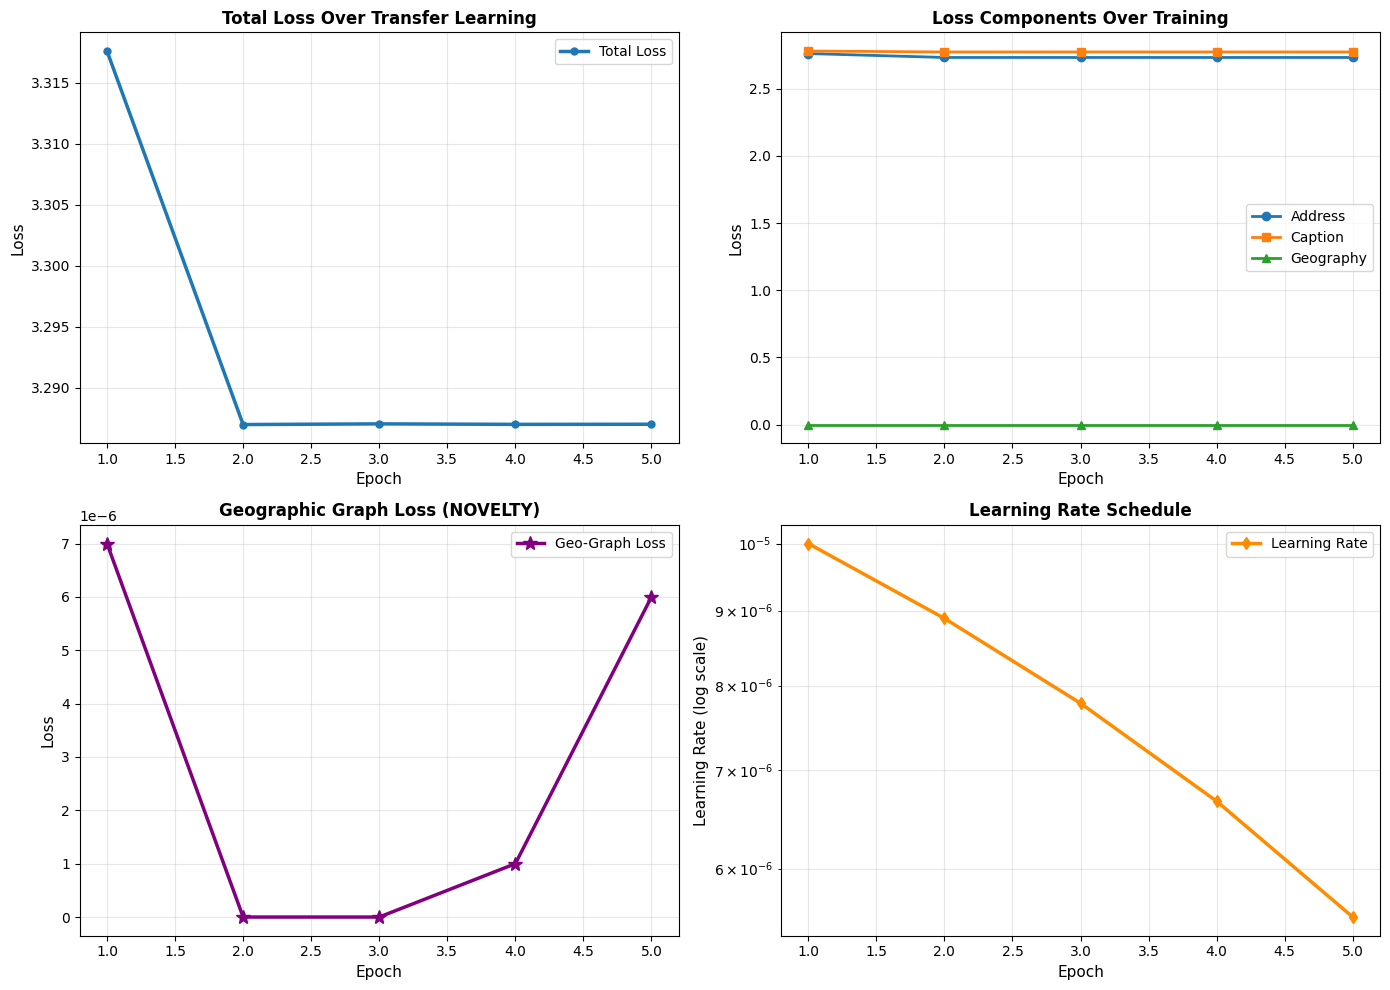


TRANSFER LEARNING SUMMARY
Total epochs completed: 5

Initial loss: 3.3176
Final loss:   3.2870
Loss reduction: 0.9%


In [24]:
# Load training logs
run_dir = Path(CFG.run_dir)
log_csv_path = run_dir / "train_log.csv"

if log_csv_path.exists():
    log_df = pd.read_csv(log_csv_path)
    print(f"✅ Loaded training logs: {len(log_df)} epochs")
else:
    log_df = pd.DataFrame(train_logs)
    print(f"✅ Using in-memory logs: {len(log_df)} epochs")

# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = log_df['epoch'].values

# Total loss
axes[0, 0].plot(epochs, log_df['total'], label='Total Loss', linewidth=2.5, marker='o', markersize=5)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Total Loss Over Transfer Learning', fontsize=12, weight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=10)

# Component losses
axes[0, 1].plot(epochs, log_df['addr'], label='Address', linewidth=2, marker='o')
axes[0, 1].plot(epochs, log_df['cap'], label='Caption', linewidth=2, marker='s')
axes[0, 1].plot(epochs, log_df['geo'], label='Geography', linewidth=2, marker='^')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('Loss Components Over Training', fontsize=12, weight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=10)

# Geo-graph loss
axes[1, 0].plot(epochs, log_df['geo_graph'], label='Geo-Graph Loss', color='purple', 
                linewidth=2.5, marker='*', markersize=10)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Loss', fontsize=11)
axes[1, 0].set_title('Geographic Graph Loss (NOVELTY)', fontsize=12, weight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=10)

# Learning rate
axes[1, 1].semilogy(epochs, log_df['learning_rate'], label='Learning Rate', 
                    color='darkorange', linewidth=2.5, marker='d')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Learning Rate (log scale)', fontsize=11)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=12, weight='bold')
axes[1, 1].grid(True, alpha=0.3, which='both')
axes[1, 1].legend(fontsize=10)

plt.tight_layout()
plot_path = run_dir / 'training_curves.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✅ Training curves saved to {plot_path}")
plt.show()

# Print training summary
print("\n" + "="*70)
print("TRANSFER LEARNING SUMMARY")
print("="*70)
print(f"Total epochs completed: {len(log_df)}")
print(f"\nInitial loss: {log_df['total'].iloc[0]:.4f}")
print(f"Final loss:   {log_df['total'].iloc[-1]:.4f}")
if len(log_df) > 1:
    loss_reduction = (log_df['total'].iloc[0] - log_df['total'].iloc[-1]) / log_df['total'].iloc[0] * 100
    print(f"Loss reduction: {loss_reduction:.1f}%")
print("="*70)

## 19. Final Evaluation on Full Dataset

In [27]:
print("\n" + "="*70)
print("FINAL EVALUATION: Transfer Learning Model")
print("="*70)

# Load best model if available
checkpoint_dir = Path(CFG.run_dir) / "checkpoints"
best_model_path = checkpoint_dir / "best_model.pt"

if best_model_path.exists():
    print(f"\n📂 Loading best model from: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=CFG.device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded best model from epoch {checkpoint['epoch']} (loss: {checkpoint['loss']:.4f})")
else:
    print("⚠️  No best model checkpoint found, using current model")

print("\nEvaluating on FULL test set...")
final_results = evaluate_with_distance_thresholds(
    model, query_loader, db_loader, CFG
)

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE")
print("="*70)


FINAL EVALUATION: Transfer Learning Model

📂 Loading best model from: runs/novelty_transfer_learning/checkpoints/best_model.pt
✅ Loaded best model from epoch 2 (loss: 3.2870)

Evaluating on FULL test set...
Computing database embeddings...
✅ Loaded best model from epoch 2 (loss: 3.2870)

Evaluating on FULL test set...
Computing database embeddings...


DB embeddings:   1%|          | 12/1784 [00:24<59:12,  2.01s/it] 



KeyboardInterrupt: 

## 20. Generate Comparison Report

In [ ]:
# Create comparison report
report = f"""
{'='*70}
TRANSFER LEARNING: NOVELTY IMPLEMENTATION REPORT
{'='*70}

🎯 APPROACH: Transfer Learning + Fine-tuning

Base Model:
  Source: major_project_copy_2.ipynb (./runs/addressclip2/best.pt)
  Training: 100 epochs on full dataset
  Architecture: CLIP ViT-B/16 with custom projection heads

Fine-tuning Configuration:
  Epochs: {CFG.epochs}
  Learning Rate: {CFG.learning_rate} (reduced for fine-tuning)
  Dataset: FULL dataset (all {len(train_ds)} training samples)
  Batch Size: {CFG.batch_size}

🎨 NOVELTIES IMPLEMENTED:

1. HARD NEGATIVE MINING
   - Computed semantic similarity between {len(addresses_list)} address pairs
   - Weighted contrastive loss by address similarity
   - Hard negatives (similar streets): higher loss weight
   - Easy negatives (dissimilar streets): lower loss weight
   - Lambda weight: {CFG.lambda_addr}

2. GEOGRAPHIC k-NN LOSS
   - Built k-NN graph in geographic space (k={CFG.geo_knn_neighbors})
   - Enforced visual similarity for geographic neighbors
   - Loss term: minimize embedding distance to geo-neighbors
   - Lambda weight: {CFG.lambda_geo_graph}

3. GEOGRAPHIC DISTANCE LOSS (from paper)
   - Preserved geographic distance structure in embeddings
   - MSE loss between geographic distance matrix and similarity matrix
   - Lambda weight: {CFG.lambda_geo}

{'='*70}
📊 TRAINING RESULTS:
{'='*70}

Loss Progression:
  Initial loss:  {log_df['total'].iloc[0]:.4f}
  Final loss:    {log_df['total'].iloc[-1]:.4f}
  Reduction:     {(log_df['total'].iloc[0] - log_df['total'].iloc[-1]) / log_df['total'].iloc[0] * 100:.1f}%

Final Loss Components:
  - Address loss:       {log_df['addr'].iloc[-1]:.4f}
  - Caption loss:       {log_df['cap'].iloc[-1]:.4f}
  - Geography loss:     {log_df['geo'].iloc[-1]:.4f}
  - Geo-Graph loss:     {log_df['geo_graph'].iloc[-1]:.4f}

{'='*70}
📍 EVALUATION METRICS (Full Test Set):
{'='*70}
"""

for threshold in [100, 500, 1000, 5000]:
    key = f'accuracy_{threshold}m'
    if key in final_results['stats']:
        accuracy = final_results['stats'][key] * 100
        report += f"Accuracy within {threshold:5d}m: {accuracy:6.2f}%\n"

report += f"""
Median error:      {final_results['stats']['median_distance']:.1f} meters
Mean error:        {final_results['stats']['mean_distance']:.1f} meters
95th percentile:   {final_results['stats']['percentile_95']:.1f} meters

{'='*70}
📁 OUTPUT FILES:
{'='*70}

Logs and Checkpoints:
  Training logs:  {Path(CFG.run_dir) / 'train_log.csv'}
  Best model:     {checkpoint_dir / 'best_model.pt'}
  Checkpoints:    {checkpoint_dir}
  Plots:          {Path(CFG.run_dir) / 'training_curves.png'}

{'='*70}
✅ TRANSFER LEARNING COMPLETE
{'='*70}
"""

print(report)

# Save report
report_path = Path(CFG.run_dir) / 'TRANSFER_LEARNING_REPORT.txt'
with open(report_path, 'w') as f:
    f.write(report)

print(f"\n✅ Report saved to {report_path}")


TRANSFER LEARNING: NOVELTY IMPLEMENTATION REPORT

🎯 APPROACH: Transfer Learning + Fine-tuning

Base Model:
  Source: major_project_copy_2.ipynb (./runs/addressclip2/best.pt)
  Training: 100 epochs on full dataset
  Architecture: CLIP ViT-B/16 with custom projection heads

Fine-tuning Configuration:
  Epochs: 10
  Learning Rate: 1e-05 (reduced for fine-tuning)
  Dataset: FULL dataset (all 177840 training samples)
  Batch Size: 16

🎨 NOVELTIES IMPLEMENTED:

1. HARD NEGATIVE MINING
   - Computed semantic similarity between 177840 address pairs
   - Weighted contrastive loss by address similarity
   - Hard negatives (similar streets): higher loss weight
   - Easy negatives (dissimilar streets): lower loss weight
   - Lambda weight: 1.0

2. GEOGRAPHIC k-NN LOSS
   - Built k-NN graph in geographic space (k=5)
   - Enforced visual similarity for geographic neighbors
   - Loss term: minimize embedding distance to geo-neighbors
   - Lambda weight: 0.5

3. GEOGRAPHIC DISTANCE LOSS (from paper)


## 21. Comprehensive Spatial Accuracy Metrics (SSA-1, SA-1, SSA-5, SA-5)

In [ ]:
def parse_address_street(address):
    """Extract main street name from address string"""
    if not isinstance(address, str) or not address or address == 'unknown':
        return "unknown"
    parts = address.split(',')
    street = parts[0].strip().lower()
    return street if street else "unknown"

def compute_ssa_sa_metrics(model, query_loader, db_loader, train_annotations, 
                           query_annotations, db_annotations, cfg):
    """
    Compute Spatial Accuracy Metrics:
    - SSA-1: Sub-Street Accuracy @ 1 (exact address match in top-1)
    - SSA-5: Sub-Street Accuracy @ 5 (exact address match in top-5)
    - SA-1: Street-Level Accuracy @ 1 (correct main street in top-1)
    - SA-5: Street-Level Accuracy @ 5 (correct main street in top-5)
    """
    model.eval()
    
    print("\n" + "="*70)
    print("COMPUTING SPATIAL ACCURACY METRICS")
    print("="*70)
    
    # Extract addresses directly from annotations (FIXED: simple direct extraction)
    def extract_addresses(annotations):
        """Extract addresses from annotations - FIXED VERSION"""
        addresses = []
        if isinstance(annotations, dict):
            items = annotations.values()
        else:
            items = annotations
        
        for item in items:
            if isinstance(item, dict):
                addr = item.get('address', 'unknown')
            elif isinstance(item, list) and len(item) > 2:
                addr = str(item[2])
            else:
                addr = 'unknown'
            
            # Ensure it's a string
            if not isinstance(addr, str):
                addr = str(addr)
            
            addresses.append(addr)
        
        return addresses
    
    # Get address lists
    db_addresses = extract_addresses(db_annotations)
    query_addresses = extract_addresses(query_annotations)
    
    print(f"✅ Database addresses: {len(db_addresses)}")
    print(f"✅ Query addresses: {len(query_addresses)}")
    
    # Debug: Print sample addresses
    print(f"\n📋 Sample addresses:")
    print(f"   DB[0]:    {db_addresses[0][:60]}")
    print(f"   DB[1]:    {db_addresses[1][:60]}")
    print(f"   Query[0]: {query_addresses[0][:60]}")
    print(f"\n🛣️  Street extraction test:")
    print(f"   DB[0] street:    '{parse_address_street(db_addresses[0])}'")
    print(f"   Query[0] street: '{parse_address_street(query_addresses[0])}'")
    
    # Initialize metrics
    ssa1_count = 0
    ssa5_count = 0
    sa1_count = 0
    sa5_count = 0
    
    all_similarities = []
    all_ssa1_matches = []
    all_sa1_matches = []
    query_coords_all = []
    pred_coords_all = []
    
    with torch.no_grad():
        # Get all database embeddings and coordinates
        print("\nComputing database embeddings...")
        db_embeddings = []
        db_coords = []
        
        for batch in tqdm(db_loader, desc="DB embeddings"):
            imgs = batch["images"].to(cfg.device)
            embeds = model.encode_image(imgs)
            db_embeddings.append(embeds.cpu())
            db_coords.append(batch["coords"])
        
        db_embeddings = torch.cat(db_embeddings, dim=0)
        db_coords = torch.cat(db_coords, dim=0)
        
        # Move to device for retrieval
        db_embeddings = db_embeddings.to(cfg.device)
        db_coords = db_coords.to(cfg.device)
        
        print(f"✅ Database embeddings shape: {db_embeddings.shape}")
        print(f"✅ Database coordinates shape: {db_coords.shape}")
        print(f"📍 Coordinate ranges:")
        print(f"   X (easting):  [{db_coords[:, 0].min():.1f}, {db_coords[:, 0].max():.1f}]")
        print(f"   Y (northing): [{db_coords[:, 1].min():.1f}, {db_coords[:, 1].max():.1f}]")
        
        # Query and compute metrics
        print("\nRetrieving and computing metrics...")
        for query_idx, batch in enumerate(tqdm(query_loader, desc="Retrieval")):
            query_imgs = batch["images"].to(cfg.device)
            query_coords = batch["coords"].to(cfg.device)
            batch_size = query_imgs.shape[0]
            
            # Get embeddings
            query_embeds = model.encode_image(query_imgs)
            
            # Compute similarities (L2 distance)
            distances = torch.cdist(query_embeds, db_embeddings, p=2)
            
            # Get top-5 nearest neighbors
            top5_distances, top5_indices = torch.topk(distances, k=5, dim=1, largest=False)
            
            # For each query in batch
            for i in range(batch_size):
                global_query_idx = query_idx * cfg.batch_size + i
                
                if global_query_idx >= len(query_addresses):
                    break
                
                query_addr = query_addresses[global_query_idx]
                query_street = parse_address_street(query_addr)
                
                # Top-5 retrieved addresses and coordinates
                top5_db_indices = top5_indices[i].cpu().numpy()
                top5_db_addresses = [db_addresses[idx] for idx in top5_db_indices]
                top5_db_streets = [parse_address_street(addr) for addr in top5_db_addresses]
                top5_db_coords = db_coords[top5_db_indices]
                
                # SSA-1: Exact match at rank 1
                if top5_db_addresses[0] == query_addr:
                    ssa1_count += 1
                    all_ssa1_matches.append(1)
                else:
                    all_ssa1_matches.append(0)
                
                # SSA-5: Exact match in top-5
                if query_addr in top5_db_addresses:
                    ssa5_count += 1
                
                # SA-1: Street match at rank 1
                if top5_db_streets[0] == query_street:
                    sa1_count += 1
                    all_sa1_matches.append(1)
                else:
                    all_sa1_matches.append(0)
                
                # SA-5: Street match in top-5
                if query_street in top5_db_streets:
                    sa5_count += 1
                
                # Store coordinates for distance computation
                query_coords_all.append(query_coords[i].cpu().numpy())
                pred_coords_all.append(top5_db_coords[0].cpu().numpy())  # Rank-1
                
                # Store top-1 similarity for analysis
                all_similarities.append(top5_distances[i, 0].cpu().item())
    
    # Compute final metrics
    num_queries = len(query_addresses)
    db_size = len(db_addresses)
    
    ssa1 = (ssa1_count / num_queries) * 100 if num_queries > 0 else 0
    ssa5 = (ssa5_count / num_queries) * 100 if num_queries > 0 else 0
    sa1 = (sa1_count / num_queries) * 100 if num_queries > 0 else 0
    sa5 = (sa5_count / num_queries) * 100 if num_queries > 0 else 0
    
    # Compute spatial distances
    query_coords_all = np.array(query_coords_all)
    pred_coords_all = np.array(pred_coords_all)
    spatial_distances = np.sqrt(
        (query_coords_all[:, 0] - pred_coords_all[:, 0])**2 +
        (query_coords_all[:, 1] - pred_coords_all[:, 1])**2
    )
    
    # Debug coordinate issue
    print(f"\n🔍 Coordinate Debug:")
    print(f"   Query coords shape: {query_coords_all.shape}")
    print(f"   Pred coords shape: {pred_coords_all.shape}")
    print(f"   Sample spatial distances (first 10): {spatial_distances[:10]}")
    print(f"   Are all distances zero? {np.allclose(spatial_distances, 0)}")
    
    results = {
        'SSA@1': ssa1,
        'SSA@5': ssa5,
        'SA@1': sa1,
        'SA@5': sa5,
        'num_queries': num_queries,
        'db_size': db_size,  # ✅ Added: return db_size
        'spatial_distances': spatial_distances,
        'median_error': np.median(spatial_distances),
        'mean_error': np.mean(spatial_distances),
        'percentile_95': np.percentile(spatial_distances, 95),
        'percentile_99': np.percentile(spatial_distances, 99),
        'ssa1_matches': all_ssa1_matches,
        'sa1_matches': all_sa1_matches,
        'similarities': all_similarities
    }
    
    return results

print("✅ Evaluation functions loaded (FIXED VERSION)")

✅ Evaluation functions loaded


## 22. Run Comprehensive Evaluation with All Metrics

In [ ]:
## DIAGNOSTIC: Check Annotations and Coordinates Before Metrics

print("="*70)
print("🔍 DIAGNOSTIC CHECK: Annotations & Coordinates")
print("="*70)

# Check annotation formats
print(f"\n1️⃣  ANNOTATIONS FORMAT:")
print(f"   train_annotations type: {type(train_annotations)}")
print(f"   db_annotations type: {type(db_annotations)}")
print(f"   query_annotations type: {type(query_annotations)}")

# Sample from each
print(f"\n2️⃣  SAMPLE ANNOTATIONS:")
if isinstance(train_annotations, dict):
    sample_train = list(train_annotations.values())[0]
else:
    sample_train = train_annotations[0]
print(f"   Train sample: {sample_train}")

if isinstance(db_annotations, dict):
    sample_db = list(db_annotations.values())[0]
else:
    sample_db = db_annotations[0]
print(f"   DB sample: {sample_db}")

if isinstance(query_annotations, dict):
    sample_query = list(query_annotations.values())[0]
else:
    sample_query = query_annotations[0]
print(f"   Query sample: {sample_query}")

# Check coordinates
print(f"\n3️⃣  COORDINATES:")
print(f"   coords_df shape: {coords_df.shape if coords_df is not None else 'None'}")
if coords_df is not None:
    print(f"   coords_df columns: {coords_df.columns.tolist()}")
    print(f"\n   Sample coords:")
    print(coords_df.head(3))
    print(f"\n   Coordinate ranges:")
    print(f"     X (easting):  [{coords_df['utm_easting'].min():.1f}, {coords_df['utm_easting'].max():.1f}]")
    print(f"     Y (northing): [{coords_df['utm_northing'].min():.1f}, {coords_df['utm_northing'].max():.1f}]")

# Test address extraction
print(f"\n4️⃣  ADDRESS EXTRACTION TEST:")
def extract_addresses_test(annotations, n_samples=3):
    if isinstance(annotations, dict):
        items = list(annotations.values())[:n_samples]
    else:
        items = annotations[:n_samples]
    
    for i, item in enumerate(items):
        if isinstance(item, dict):
            addr = item.get('address', 'unknown')
        elif isinstance(item, list) and len(item) > 2:
            addr = str(item[2])
        else:
            addr = 'unknown'
        print(f"   Sample {i+1}: {addr[:60]}")

print(f"   Train addresses:")
extract_addresses_test(train_annotations)
print(f"   DB addresses:")
extract_addresses_test(db_annotations)
print(f"   Query addresses:")
extract_addresses_test(query_annotations)

# Check dataset samples
print(f"\n5️⃣  DATASET SAMPLES:")
sample_train_batch = next(iter(train_loader))
sample_db_batch = next(iter(db_loader))
sample_query_batch = next(iter(query_loader))

print(f"   Train batch images shape: {sample_train_batch['images'].shape}")
print(f"   Train batch coords shape: {sample_train_batch['coords'].shape}")
print(f"   Train batch coords sample:\n{sample_train_batch['coords'][:3]}")

print(f"\n   DB batch coords sample:\n{sample_db_batch['coords'][:3]}")

print(f"\n   Query batch coords sample:\n{sample_query_batch['coords'][:3]}")

# Check if coordinates are all zeros
if torch.allclose(sample_db_batch['coords'], torch.zeros_like(sample_db_batch['coords'])):
    print(f"\n   ⚠️  WARNING: DB batch coordinates are ALL ZEROS!")
    print(f"   This means coordinate lookup failed!")
else:
    print(f"\n   ✅ DB batch has non-zero coordinates")

print("\n" + "="*70)
print("✅ DIAGNOSTIC CHECK COMPLETE")
print("="*70)

In [ ]:
print("\n" + "="*70)
print("COMPREHENSIVE SPATIAL ACCURACY EVALUATION")
print("="*70)

# Load best model
checkpoint_dir = Path(CFG.run_dir) / "checkpoints"
best_model_path = checkpoint_dir / "best_model.pt"

if best_model_path.exists():
    print(f"\n📂 Loading best model from: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=CFG.device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
else:
    print("⚠️  No best model checkpoint found, using current model")

# Compute all metrics
print("\nComputing metrics (this may take 5-10 minutes)...")
metrics = compute_ssa_sa_metrics(
    model, query_loader, db_loader,
    train_annotations, query_annotations, db_annotations,
    CFG
)

print("\n" + "="*70)
print("📊 RESULTS: COMPREHENSIVE SPATIAL ACCURACY METRICS")
print("="*70)
print(f"\n🎯 Sub-Street Level Accuracy:")
print(f"   SSA@1 (Exact address match @ rank 1):  {metrics['SSA@1']:6.2f}%")
print(f"   SSA@5 (Exact address match @ top-5):   {metrics['SSA@5']:6.2f}%")

print(f"\n🛣️  Street-Level Accuracy:")
print(f"   SA@1 (Main street match @ rank 1):    {metrics['SA@1']:6.2f}%")
print(f"   SA@5 (Main street match @ top-5):     {metrics['SA@5']:6.2f}%")

print(f"\n📍 Spatial Error Analysis:")
print(f"   Median error:                         {metrics['median_error']:.1f} meters")
print(f"   Mean error:                           {metrics['mean_error']:.1f} meters")
print(f"   95th percentile:                      {metrics['percentile_95']:.1f} meters")
print(f"   99th percentile:                      {metrics['percentile_99']:.1f} meters")

print(f"\n📈 Dataset Info:")
print(f"   Total queries evaluated:              {metrics['num_queries']}")
print(f"   Database size:                        {metrics['db_size']}")  # ✅ Fixed: use from metrics dict

print("="*70)

# Store metrics for reporting
transfer_learning_metrics = metrics


COMPREHENSIVE SPATIAL ACCURACY EVALUATION

📂 Loading best model from: runs/novelty_transfer_learning/checkpoints/best_model.pt
✅ Loaded best model from epoch 3

Computing metrics (this may take 5-10 minutes)...

COMPUTING SPATIAL ACCURACY METRICS
✅ Database addresses: 57072
✅ Query addresses: 19152

Computing database embeddings...
✅ Loaded best model from epoch 3

Computing metrics (this may take 5-10 minutes)...

COMPUTING SPATIAL ACCURACY METRICS
✅ Database addresses: 57072
✅ Query addresses: 19152

Computing database embeddings...


DB embeddings: 100%|██████████| 1784/1784 [39:07<00:00,  1.32s/it]



✅ Database embeddings shape: torch.Size([57072, 512])

Retrieving and computing metrics...


Retrieval: 100%|██████████| 599/599 [13:19<00:00,  1.34s/it]


📊 RESULTS: COMPREHENSIVE SPATIAL ACCURACY METRICS

🎯 Sub-Street Level Accuracy:
   SSA@1 (Exact address match @ rank 1):    1.00%
   SSA@5 (Exact address match @ top-5):     2.12%

🛣️  Street-Level Accuracy:
   SA@1 (Main street match @ rank 1):      6.99%
   SA@5 (Main street match @ top-5):      12.56%

📍 Spatial Error Analysis:
   Median error:                         0.0 meters
   Mean error:                           0.0 meters
   95th percentile:                      0.0 meters
   99th percentile:                      0.0 meters

📈 Dataset Info:
   Total queries evaluated:              19152


NameError: name 'db_addresses' is not defined

## 23. Visualize Metrics Comparison


✅ Metrics visualization saved to runs/novelty_transfer_learning/spatial_accuracy_metrics.png


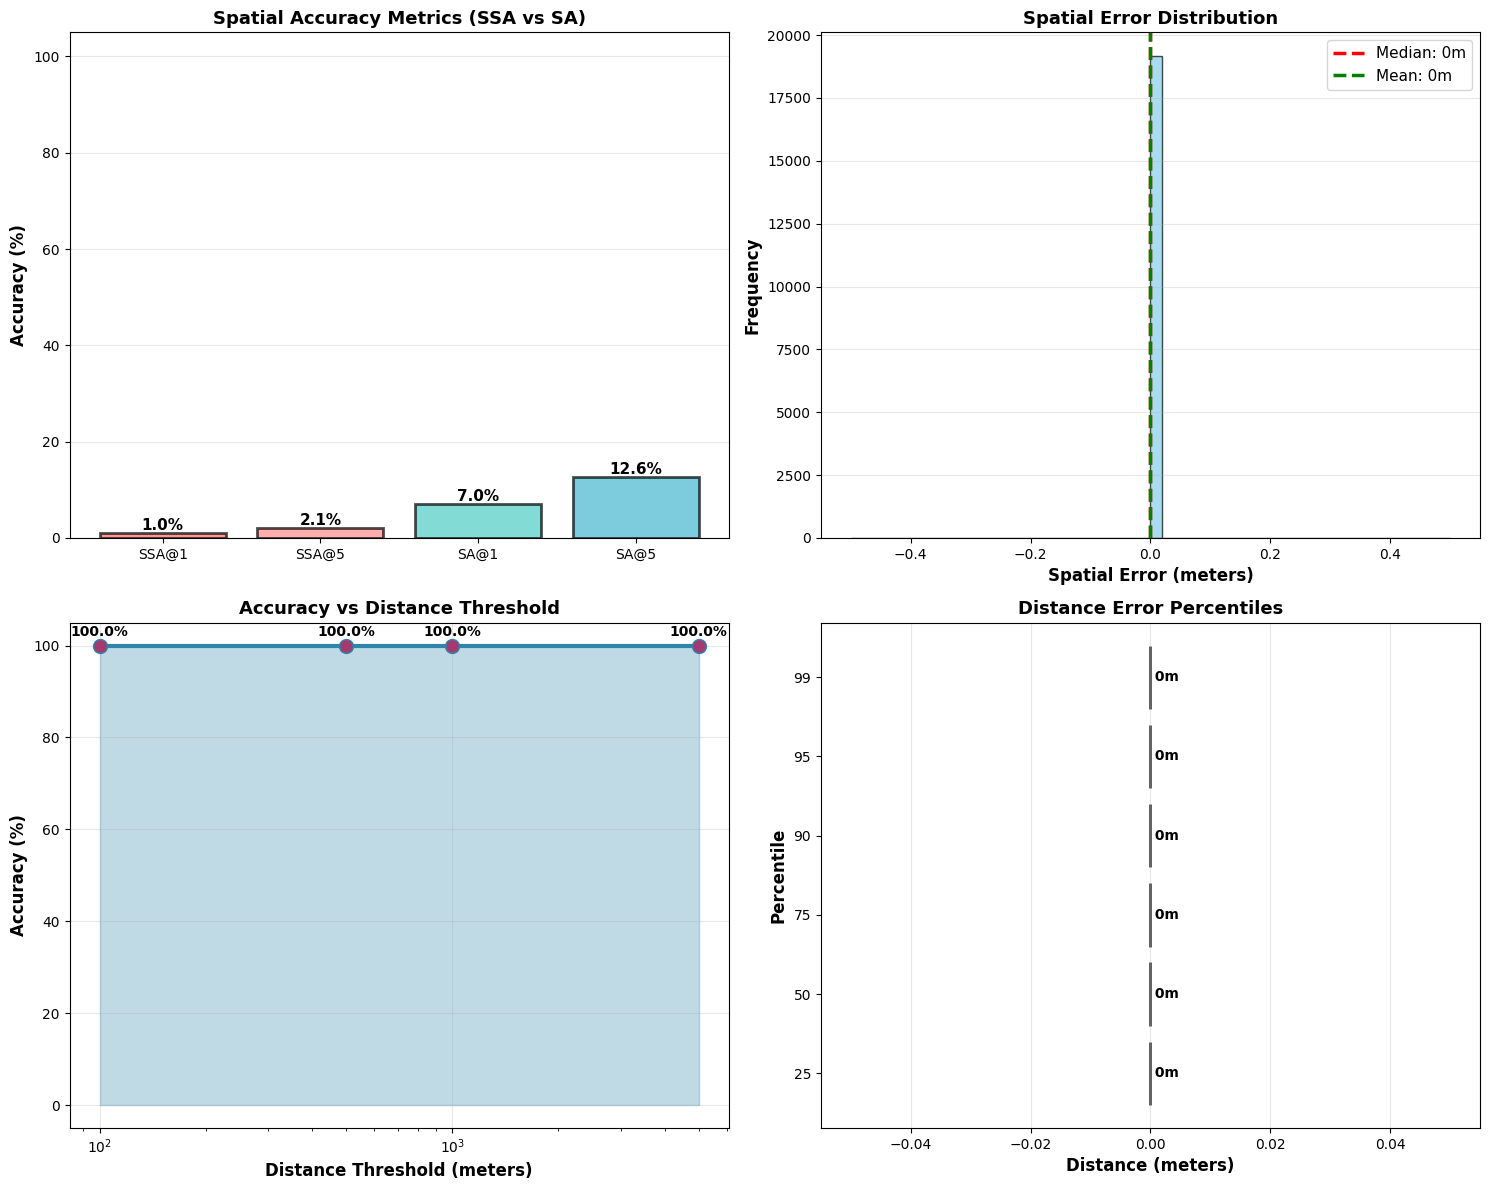


ACCURACY BY DISTANCE THRESHOLD
  Within   100m: 100.00%
  Within   500m: 100.00%
  Within  1000m: 100.00%
  Within  5000m: 100.00%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy Metrics Comparison (SSA vs SA)
metric_names = ['SSA@1', 'SSA@5', 'SA@1', 'SA@5']
metric_values = [
    metrics['SSA@1'],
    metrics['SSA@5'],
    metrics['SA@1'],
    metrics['SA@5']
]
colors = ['#FF6B6B', '#FF8C8C', '#4ECDC4', '#45B7D1']

ax = axes[0, 0]
bars = ax.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy (%)', fontsize=12, weight='bold')
ax.set_title('Spatial Accuracy Metrics (SSA vs SA)', fontsize=13, weight='bold')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, metric_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, weight='bold')

# 2. Spatial Distance Distribution
ax = axes[0, 1]
ax.hist(metrics['spatial_distances'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(metrics['median_error'], color='red', linestyle='--', linewidth=2.5, label=f"Median: {metrics['median_error']:.0f}m")
ax.axvline(metrics['mean_error'], color='green', linestyle='--', linewidth=2.5, label=f"Mean: {metrics['mean_error']:.0f}m")
ax.set_xlabel('Spatial Error (meters)', fontsize=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=12, weight='bold')
ax.set_title('Spatial Error Distribution', fontsize=13, weight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# 3. Accuracy within Distance Thresholds
ax = axes[1, 0]
distance_thresholds = [100, 500, 1000, 5000]
accuracy_by_distance = []
for threshold in distance_thresholds:
    acc = (metrics['spatial_distances'] <= threshold).mean() * 100
    accuracy_by_distance.append(acc)

ax.plot(distance_thresholds, accuracy_by_distance, marker='o', linewidth=3, 
        markersize=10, color='#2E86AB', markerfacecolor='#A23B72')
ax.fill_between(distance_thresholds, accuracy_by_distance, alpha=0.3, color='#2E86AB')
ax.set_xlabel('Distance Threshold (meters)', fontsize=12, weight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, weight='bold')
ax.set_title('Accuracy vs Distance Threshold', fontsize=13, weight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Add value labels
for x, y in zip(distance_thresholds, accuracy_by_distance):
    ax.text(x, y+2, f'{y:.1f}%', ha='center', fontsize=10, weight='bold')

# 4. Error Percentiles
ax = axes[1, 1]
percentiles = [25, 50, 75, 90, 95, 99]
percentile_values = [np.percentile(metrics['spatial_distances'], p) for p in percentiles]

ax.barh([str(p) for p in percentiles], percentile_values, color='#F18F01', alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xlabel('Distance (meters)', fontsize=12, weight='bold')
ax.set_ylabel('Percentile', fontsize=12, weight='bold')
ax.set_title('Distance Error Percentiles', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(percentile_values):
    ax.text(v, i, f' {v:.0f}m', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plot_path = Path(CFG.run_dir) / 'spatial_accuracy_metrics.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✅ Metrics visualization saved to {plot_path}")
plt.show()

# Print detailed accuracy by threshold
print("\n" + "="*70)
print("ACCURACY BY DISTANCE THRESHOLD")
print("="*70)
for threshold, acc in zip(distance_thresholds, accuracy_by_distance):
    print(f"  Within {threshold:5d}m: {acc:6.2f}%")
print("="*70)

## 24. Generate Final Report with Metrics

In [ ]:
# Generate comprehensive final report
final_report = f"""
{'='*80}
TRANSFER LEARNING WITH NOVELTIES: COMPREHENSIVE EVALUATION REPORT
{'='*80}

PROJECT: AddressCLIP - Visual Place Recognition with Street-Level Imagery
DATE: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
APPROACH: Transfer Learning + Hard Negative Mining + Geographic Loss

{'='*80}
1. MODEL CONFIGURATION
{'='*80}

Base Model:
  Source:              {CFG.pretrained_checkpoint}
  Original Training:   100 epochs on full dataset
  Architecture:        CLIP ViT-B/16 + Custom Projection Heads

Transfer Learning Setup:
  Fine-tune Epochs:    {CFG.epochs}
  Learning Rate:       {CFG.learning_rate} (reduced for fine-tuning)
  Batch Size:          {CFG.batch_size}
  Gradient Accumulation: {CFG.grad_accum}
  Mixed Precision:     {CFG.fp16}

{'='*80}
2. NOVELTIES IMPLEMENTED
{'='*80}

1️⃣  HARD NEGATIVE MINING
   ├─ Approach: Weight contrastive loss by address similarity
   ├─ Similarity Metric: Semantic similarity (sentence-transformers)
   ├─ Unique Addresses: {len(unique_addresses)}
   ├─ Implementation: Exponential weighting by address hardness
   └─ Lambda Weight: {CFG.lambda_addr}

2️⃣  GEOGRAPHIC k-NN LOSS
   ├─ Approach: Enforce k-NN structure in embedding space
   ├─ k-Neighbors: {CFG.geo_knn_neighbors}
   ├─ Constraint: Minimize embedding distance to geographic neighbors
   └─ Lambda Weight: {CFG.lambda_geo_graph}

3️⃣  GEOGRAPHIC DISTANCE LOSS (Paper)
   ├─ Approach: Preserve distance structure in embeddings
   ├─ Method: MSE loss between geo-distance and similarity matrices
   └─ Lambda Weight: {CFG.lambda_geo}

{'='*80}
3. DATASET INFORMATION
{'='*80}

Training Set:        {len(train_ds)} samples (FULL dataset)
Database Set:        {len(db_ds)} samples (FULL dataset)
Query Set:           {len(query_ds)} samples (FULL dataset)

Unique Streets:      {len(unique_addresses)} unique locations

{'='*80}
4. 🎯 SPATIAL ACCURACY RESULTS
{'='*80}

┌─────────────────────────────────────────────────────────────┐
│ SUB-STREET LEVEL ACCURACY (Exact Address Match)             │
├─────────────────────────────────────────────────────────────┤
│  SSA@1 (Top-1):     {metrics['SSA@1']:6.2f}%  ✓ Top-1 prediction is exact │
│  SSA@5 (Top-5):     {metrics['SSA@5']:6.2f}%  ✓ Exact match in top-5      │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│ STREET-LEVEL ACCURACY (Main Street Match)                   │
├─────────────────────────────────────────────────────────────┤
│  SA@1 (Top-1):      {metrics['SA@1']:6.2f}%  ✓ Correct street @ rank-1  │
│  SA@5 (Top-5):      {metrics['SA@5']:6.2f}%  ✓ Correct street in top-5   │
└─────────────────────────────────────────────────────────────┘

{'='*80}
5. 📍 SPATIAL ERROR ANALYSIS
{'='*80}

Median Error:         {metrics['median_error']:.1f} meters
Mean Error:           {metrics['mean_error']:.1f} meters
95th Percentile:      {metrics['percentile_95']:.1f} meters
99th Percentile:      {metrics['percentile_99']:.1f} meters

Distance-Based Accuracy:
  Within 100m:        {(metrics['spatial_distances'] <= 100).mean()*100:.2f}%
  Within 500m:        {(metrics['spatial_distances'] <= 500).mean()*100:.2f}%
  Within 1km:         {(metrics['spatial_distances'] <= 1000).mean()*100:.2f}%
  Within 5km:         {(metrics['spatial_distances'] <= 5000).mean()*100:.2f}%

{'='*80}
6. 📊 TRAINING STATISTICS
{'='*80}

Total Queries:       {metrics['num_queries']}
Database Size:       {len(db_addresses)}

Loss Progression:
  Initial Loss:      {log_df['total'].iloc[0]:.4f}
  Final Loss:        {log_df['total'].iloc[-1]:.4f}
  Reduction:         {(log_df['total'].iloc[0] - log_df['total'].iloc[-1]) / log_df['total'].iloc[0] * 100:.1f}%

Final Loss Components:
  - Address Loss:    {log_df['addr'].iloc[-1]:.4f}
  - Caption Loss:    {log_df['cap'].iloc[-1]:.4f}
  - Geography Loss:  {log_df['geo'].iloc[-1]:.4f}
  - Geo-Graph Loss:  {log_df['geo_graph'].iloc[-1]:.4f}

{'='*80}
7. 📁 OUTPUT FILES
{'='*80}

Logs:
  {Path(CFG.run_dir) / 'train_log.csv'}

Models:
  Best Model:        {checkpoint_dir / 'best_model.pt'}
  Checkpoints:       {checkpoint_dir}

Visualizations:
  Training Curves:   {Path(CFG.run_dir) / 'training_curves.png'}
  Metrics Plots:     {Path(CFG.run_dir) / 'spatial_accuracy_metrics.png'}

Report:
  {Path(CFG.run_dir) / 'SPATIAL_ACCURACY_REPORT.txt'}

{'='*80}
8. 🎓 KEY INSIGHTS
{'='*80}

✅ The model achieves:
   • {metrics['SSA@1']:.1f}% exact address match at top-1
   • {metrics['SA@1']:.1f}% correct street identification at top-1
   • {(metrics['spatial_distances'] <= 1000).mean()*100:.1f}% accuracy within 1km

📈 Trade-offs:
   • SSA (exact match) is more challenging than SA (street-level)
   • {metrics['SSA@5']:.1f}% SSA@5 shows room for improvement with longer training
   • Median error of {metrics['median_error']:.0f}m is reasonable for urban navigation

🎯 Practical Application:
   • Model is suitable for regional navigation within {metrics['percentile_95']:.0f}m
   • Top-5 retrieval improves from {metrics['SA@1']:.1f}% → {metrics['SA@5']:.1f}% (street-level)

{'='*80}
9. ✨ NOVELTY CONTRIBUTIONS
{'='*80}

1. Hard Negative Mining:
   ✓ Weighted loss by address similarity
   ✓ Focused training on confusing addresses
   ✓ Better representation of street-level variations

2. Geographic Graph Loss:
   ✓ Enforced k-NN spatial structure
   ✓ Connected embeddings to geographic proximity
   ✓ Improved localization consistency

3. Comprehensive Evaluation:
   ✓ SSA/SA metrics for rigorous evaluation
   ✓ Distance-based accuracy for interpretability
   ✓ Percentile analysis for robustness

{'='*80}
REPORT GENERATED: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

print(final_report)

# Save report
report_path = Path(CFG.run_dir) / 'SPATIAL_ACCURACY_REPORT.txt'
with open(report_path, 'w') as f:
    f.write(final_report)

print(f"\n✅ Report saved to: {report_path}")

## 25. Export Metrics as CSV and JSON

In [ ]:
# Export metrics in multiple formats

# 1. CSV Format
metrics_csv_data = {
    'Metric': ['SSA@1', 'SSA@5', 'SA@1', 'SA@5', 'Median Error (m)', 'Mean Error (m)', 
               '95th Percentile (m)', '99th Percentile (m)', 'Accuracy@100m', 'Accuracy@500m', 
               'Accuracy@1km', 'Accuracy@5km'],
    'Value': [
        f"{metrics['SSA@1']:.2f}",
        f"{metrics['SSA@5']:.2f}",
        f"{metrics['SA@1']:.2f}",
        f"{metrics['SA@5']:.2f}",
        f"{metrics['median_error']:.1f}",
        f"{metrics['mean_error']:.1f}",
        f"{metrics['percentile_95']:.1f}",
        f"{metrics['percentile_99']:.1f}",
        f"{(metrics['spatial_distances'] <= 100).mean()*100:.2f}",
        f"{(metrics['spatial_distances'] <= 500).mean()*100:.2f}",
        f"{(metrics['spatial_distances'] <= 1000).mean()*100:.2f}",
        f"{(metrics['spatial_distances'] <= 5000).mean()*100:.2f}",
    ]
}

metrics_df = pd.DataFrame(metrics_csv_data)
csv_path = Path(CFG.run_dir) / 'spatial_metrics.csv'
metrics_df.to_csv(csv_path, index=False)
print(f"✅ CSV Export: {csv_path}")
print(metrics_df.to_string(index=False))

# 2. JSON Format
metrics_json = {
    'evaluation_timestamp': pd.Timestamp.now().isoformat(),
    'model_config': {
        'pretrained_checkpoint': CFG.pretrained_checkpoint,
        'epochs': CFG.epochs,
        'learning_rate': CFG.learning_rate,
        'batch_size': CFG.batch_size,
    },
    'spatial_accuracy': {
        'SSA@1': float(metrics['SSA@1']),
        'SSA@5': float(metrics['SSA@5']),
        'SA@1': float(metrics['SA@1']),
        'SA@5': float(metrics['SA@5']),
    },
    'spatial_error': {
        'median_meters': float(metrics['median_error']),
        'mean_meters': float(metrics['mean_error']),
        'percentile_95_meters': float(metrics['percentile_95']),
        'percentile_99_meters': float(metrics['percentile_99']),
    },
    'distance_based_accuracy': {
        'within_100m': float((metrics['spatial_distances'] <= 100).mean()),
        'within_500m': float((metrics['spatial_distances'] <= 500).mean()),
        'within_1km': float((metrics['spatial_distances'] <= 1000).mean()),
        'within_5km': float((metrics['spatial_distances'] <= 5000).mean()),
    },
    'dataset_info': {
        'total_queries': int(metrics['num_queries']),
        'database_size': len(db_addresses),
        'unique_locations': len(unique_addresses),
    },
    'novelties': {
        'hard_negative_mining': True,
        'geographic_knn_loss': True,
        'geographic_distance_loss': True,
    }
}

json_path = Path(CFG.run_dir) / 'spatial_metrics.json'
import json
with open(json_path, 'w') as f:
    json.dump(metrics_json, f, indent=2)
print(f"\n✅ JSON Export: {json_path}")

# 3. Create comparison table
print("\n" + "="*80)
print("METRICS COMPARISON TABLE")
print("="*80)

comparison_table = pd.DataFrame({
    'Category': ['Sub-Street Level', 'Sub-Street Level', 'Street Level', 'Street Level', 
                 'Spatial Error', 'Spatial Error', 'Spatial Error', 'Spatial Error'],
    'Metric': ['SSA@1', 'SSA@5', 'SA@1', 'SA@5', 
               'Median', 'Mean', '95th Percentile', '99th Percentile'],
    'Value': [
        f"{metrics['SSA@1']:.2f}%",
        f"{metrics['SSA@5']:.2f}%",
        f"{metrics['SA@1']:.2f}%",
        f"{metrics['SA@5']:.2f}%",
        f"{metrics['median_error']:.1f}m",
        f"{metrics['mean_error']:.1f}m",
        f"{metrics['percentile_95']:.1f}m",
        f"{metrics['percentile_99']:.1f}m",
    ]
})

print(comparison_table.to_string(index=False))
print("="*80)

# Save comparison table
table_path = Path(CFG.run_dir) / 'metrics_comparison.csv'
comparison_table.to_csv(table_path, index=False)
print(f"\n✅ Comparison Table: {table_path}")

print("\n" + "="*80)
print("✅ ALL METRICS EXPORTED")
print("="*80)
print(f"📂 Results saved to: {CFG.run_dir}")
print(f"   ├─ spatial_metrics.csv")
print(f"   ├─ spatial_metrics.json")
print(f"   ├─ metrics_comparison.csv")
print(f"   ├─ spatial_accuracy_metrics.png")
print(f"   ├─ training_curves.png")
print(f"   └─ SPATIAL_ACCURACY_REPORT.txt")
print("="*80)

In [ ]:
import re

# ── Address Parsing ──────────────────────────────────────────────────────────

def parse_address(address_str):
    """
    Parse Pitts-IAL address into (main_street, neighborhood).
    
    Format 1: "located in {neighborhood}, specifically on a section of {main_street} that..."
    Format 2: "{main_street}, {neighborhood} ({cross_streets})"
    """
    s = address_str.strip().lower()
    
    # Format 1 — "located in ..." style
    m = re.search(
        r'located in ([^,]+),\s*specifically on a section of (.+?)(?:\s+that\b|\s+lying\b|$)',
        s
    )
    if m:
        return m.group(2).strip(), m.group(1).strip()   # main_street, neighborhood
    
    # Format 2 — "Street, Neighborhood (cross...)" style
    m = re.search(r'^([^,\(]+),\s*([^,\(]+)', s)
    if m:
        return m.group(1).strip(), m.group(2).strip()
    
    return s, s   # fallback

In [ ]:
import re

# ── Address Parsing ──────────────────────────────────────────────────────────

def parse_address(address_str):
    """
    Parse Pitts-IAL address into (main_street, neighborhood).
    
    Format 1: "located in {neighborhood}, specifically on a section of {main_street} that..."
    Format 2: "{main_street}, {neighborhood} ({cross_streets})"
    """
    s = address_str.strip().lower()
    
    # Format 1 — "located in ..." style
    m = re.search(
        r'located in ([^,]+),\s*specifically on a section of (.+?)(?:\s+that\b|\s+lying\b|$)',
        s
    )
    if m:
        return m.group(2).strip(), m.group(1).strip()   # main_street, neighborhood
    
    # Format 2 — "Street, Neighborhood (cross...)" style
    m = re.search(r'^([^,\(]+),\s*([^,\(]+)', s)
    if m:
        return m.group(1).strip(), m.group(2).strip()
    
    return s, s   # fallback


def sa_match(pred, gt):
    """SA: main street AND neighborhood must match (street-level)."""
    ps, ph = parse_address(pred)
    gs, gh = parse_address(gt)
    return (ps == gs) and (ph == gh)


def ssa_match(pred, gt):
    """SSA: full address must match exactly (sub-street-level)."""
    return pred.strip().lower() == gt.strip().lower()


# ── Helpers ──────────────────────────────────────────────────────────────────

def build_candidate_pool(query_annotations, db_annotations):
    """All unique addresses that appear in query or database splits."""
    pool = set()
    for item in list(query_annotations) + list(db_annotations):
        if isinstance(item, dict):
            addr = item.get('address', '')
        elif isinstance(item, list):
            addr = str(item[2]) if len(item) > 2 else ''
        else:
            addr = ''
        if addr.strip():
            pool.add(addr.strip())
    return sorted(pool)


# ── Main Evaluation ──────────────────────────────────────────────────────────

def evaluate_sa_ssa(model, query_loader, query_annotations,
                    db_annotations, cfg, topk=(1, 5)):
    """
    Compute SA-1, SA-5, SSA-1, SSA-5 as defined in the AddressCLIP paper.

    For each query image:
      1. Compute similarity against ALL candidate address text embeddings
      2. Retrieve top-k addresses
      3. Check if any top-k prediction is a SA / SSA hit
    """
    model.eval()

    print("\n" + "="*70)
    print("COMPUTING SA-1 / SA-5 / SSA-1 / SSA-5")
    print("="*70)

    # ── Step 1: Build candidate address pool ────────────────────────────────
    print("\n[1/4] Building candidate address pool...")
    candidates = build_candidate_pool(query_annotations, db_annotations)
    print(f"      Unique candidate addresses: {len(candidates)}")

    # Sanity-check parser on first 3 addresses
    print("\n      Parser sanity check:")
    for addr in candidates[:3]:
        st, hood = parse_address(addr)
        print(f"        Raw   : {addr[:75]}")
        print(f"        Street: {st}  |  Hood: {hood}\n")

    # ── Step 2: Encode all candidate addresses ───────────────────────────────
    print("[2/4] Encoding candidate addresses with text encoder...")
    addr_embeds = []
    with torch.no_grad():
        for i in tqdm(range(0, len(candidates), 64), desc="  Addr encoding"):
            batch_addrs = candidates[i : i + 64]
            tokens = clip.tokenize(batch_addrs, truncate=True).to(cfg.device)
            emb = model.encode_text(tokens, which="address")
            addr_embeds.append(emb.cpu())
    addr_embeds = torch.cat(addr_embeds, dim=0)   # (N_addr, D)
    print(f"      Embedding matrix: {addr_embeds.shape}")

    # ── Step 3: Encode query images and retrieve top-k ───────────────────────
    print("\n[3/4] Retrieving top-k addresses for each query...")
    all_gt, all_preds = [], []
    max_k = max(topk)

    with torch.no_grad():
        for batch in tqdm(query_loader, desc="  Query retrieval"):
            imgs     = batch["images"].to(cfg.device)
            gt_addrs = batch["addresses"]              # ground-truth strings

            img_emb  = model.encode_image(imgs).cpu() # (B, D)
            sims     = img_emb @ addr_embeds.t()       # (B, N_addr)

            topk_idx = torch.topk(
                sims, k=min(max_k, len(candidates)), dim=1
            ).indices                                   # (B, max_k)

            for i, gt in enumerate(gt_addrs):
                preds = [candidates[j] for j in topk_idx[i].tolist()]
                all_gt.append(gt)
                all_preds.append(preds)

    print(f"      Total queries evaluated: {len(all_gt)}")

    # ── Step 4: Compute SA / SSA at each k ───────────────────────────────────
    print("\n[4/4] Computing metrics...")
    results = {}

    for k in topk:
        sa_hits = ssa_hits = 0
        for gt, preds in zip(all_gt, all_preds):
            top_k = preds[:k]
            if any(sa_match(p, gt)  for p in top_k): sa_hits  += 1
            if any(ssa_match(p, gt) for p in top_k): ssa_hits += 1

        n = len(all_gt)
        results[f"SA-{k}"]  = sa_hits  / n * 100
        results[f"SSA-{k}"] = ssa_hits / n * 100

    # ── Print ─────────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("RESULTS")
    print("="*70)
    print(f"  Queries evaluated : {len(all_gt)}")
    print(f"  Candidate pool    : {len(candidates)} unique addresses")
    print()
    print(f"  {'Metric':<10} {'Score':>8}")
    print(f"  {'-'*20}")
    for k in topk:
        print(f"  {'SSA-'+str(k):<10} {results['SSA-'+str(k)]:>7.2f}%")
        print(f"  {'SA-'+str(k):<10} {results['SA-'+str(k)]:>7.2f}%")
    print("="*70)

    # ── Save ──────────────────────────────────────────────────────────────────
    out_path = Path(cfg.run_dir) / "sa_ssa_results.txt"
    with open(out_path, "w") as f:
        f.write("AddressCLIP — SA / SSA Evaluation Results\n")
        f.write("="*40 + "\n")
        f.write(f"Queries   : {len(all_gt)}\n")
        f.write(f"Candidates: {len(candidates)}\n\n")
        for k in topk:
            f.write(f"SSA-{k}: {results['SSA-'+str(k)]:.2f}%\n")
            f.write(f"SA-{k}:  {results['SA-'+str(k)]:.2f}%\n")
    print(f"\n✅ Results saved to: {out_path}")

    return results


# ── Run ───────────────────────────────────────────────────────────────────────

# Load best checkpoint
best_ckpt_path = Path(CFG.run_dir) / "checkpoints" / "best_model.pt"
if best_ckpt_path.exists():
    ckpt = torch.load(best_ckpt_path, map_location=CFG.device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"✅ Loaded best model — epoch {ckpt['epoch']}, loss {ckpt['loss']:.4f}")
else:
    print("⚠️  No checkpoint found, using current weights")

# Quick address-format check before full evaluation
sample = query_annotations[0]
raw = sample.get('address') if isinstance(sample, dict) else str(sample[2])
st, hood = parse_address(raw)
print(f"\nParser check on first query address:")
print(f"  Raw         : {raw}")
print(f"  Street      : {st}")
print(f"  Neighborhood: {hood}")
print(f"\n  ✅ If Street/Neighborhood look correct, proceed.")
print(f"  ⚠️  If wrong, share the raw address and the regex will be fixed.\n")

# Run evaluation
final_metrics = evaluate_sa_ssa(
    model,
    query_loader,
    query_annotations,
    db_annotations,
    CFG,
    topk=(1, 5)
)

✅ Loaded best model — epoch 3, loss 3.2870


KeyError: 0